# Phase 5: RFM Customer Segmentation

Recency/Frequency/Monetary scoring (quintiles, 1-5) and assignment of actionable customer segments. Segment revenue share, margin and recency drive the retention recommendations in the business report.

## Load cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
df = pd.read_csv('../data/cleaned/retail_sales_clean.csv', parse_dates=['Order_Date'])
REFERENCE = pd.Timestamp('2024-12-31')
print(df.shape)

(108045, 30)


## 1. Compute Recency / Frequency / Monetary per customer

In [2]:
rfm = df.groupby('Customer_ID').agg(
    last_order=('Order_Date', 'max'),
    orders=('Order_ID', 'nunique'),
    monetary=('Sales', 'sum'),
    profit=('Profit', 'sum')).reset_index()
rfm['recency_days'] = (REFERENCE - rfm['last_order']).dt.days
rfm['recency_weeks'] = rfm['recency_days'] // 7
print(rfm.describe().round(1))

       Customer_ID                     last_order  orders  monetary    profit  \
count       1648.0                           1648  1648.0    1648.0    1648.0   
mean         906.8  2024-07-11 13:12:31.456310528    20.2   41811.4    9949.5   
min            1.0            2021-01-01 00:00:00     1.0       8.7   -1774.8   
25%          454.8            2024-06-02 12:00:00     4.0    5283.0    1330.5   
50%          911.5            2024-11-13 00:00:00    11.0   18301.9    4348.2   
75%         1359.2            2024-12-17 00:00:00    26.0   48967.7   11885.3   
max         1800.0            2024-12-31 00:00:00   310.0  857086.8  204914.8   
std          521.0                            NaN    26.7   66630.3   15808.3   

       recency_days  recency_weeks  
count        1648.0         1648.0  
mean          172.4           24.2  
min             0.0            0.0  
25%            14.0            2.0  
50%            48.0            6.0  
75%           211.5           30.0  
max        

## 2. Score each dimension 1-5 (quintiles)
Recency is inverted — fewer days since last purchase scores higher.

In [3]:
def score(s, reverse=False):
    qs = s.quantile([0.2, 0.4, 0.6, 0.8]).values
    labels = [1, 2, 3, 4, 5] if not reverse else [5, 4, 3, 2, 1]
    return pd.cut(s, bins=[-np.inf, *qs, np.inf], labels=labels, include_lowest=True).astype(int)

rfm['R'] = score(rfm['recency_days'], reverse=True)
rfm['F'] = score(rfm['orders'])
rfm['M'] = score(rfm['monetary'])
rfm['RFM_Score'] = rfm['R'] * 100 + rfm['F'] * 10 + rfm['M']
rfm[['R', 'F', 'M']].value_counts().head(10)

R  F  M
1  1  1    161
5  5  5    141
4  5  5     93
2  2  2     61
3  4  4     61
2  1  1     60
5  4  4     55
4  4  4     55
1  1  2     54
   2  2     54
Name: count, dtype: int64

## 3. Assign business segments
Standard RFM segmentation rules (documented in the README and report).

In [4]:
def segment(r):
    R, F, M, n = r['R'], r['F'], r['M'], r['orders']
    if R >= 4 and F >= 4 and M >= 4: return 'Champions'
    if R >= 3 and F >= 4 and M >= 4: return 'Loyal Customers'
    if R >= 4 and n <= 2: return 'New Customers'
    if R >= 4 and (F >= 3 or M >= 3): return 'Potential Loyalists'
    if R >= 4: return 'Promising'
    if R <= 2 and F >= 4 and M >= 4: return "Can't Lose"
    if R <= 2 and F >= 3 and M >= 3: return 'At Risk'
    if R <= 2: return 'Lost'
    if F <= 2 and M <= 2: return 'Hibernating'
    return 'Promising'

rfm['Segment'] = rfm.apply(segment, axis=1)
seg = rfm.groupby('Segment').agg(customers=('Customer_ID', 'nunique'),
    revenue=('monetary', 'sum'), avg_spend=('monetary', 'mean'),
    avg_orders=('orders', 'mean'), avg_recency_weeks=('recency_weeks', 'mean')).round(0)
seg['revenue_share'] = seg['revenue'] / seg['revenue'].sum()
seg['margin'] = rfm.groupby('Segment').profit.sum() / seg['revenue']
print(seg.to_string())

                     customers     revenue  avg_spend  avg_orders  avg_recency_weeks  revenue_share    margin
Segment                                                                                                      
At Risk                     80   1836216.0    22953.0        13.0               26.0       0.026648  0.242089
Can't Lose                  43   2245484.0    52221.0        24.0               18.0       0.032588  0.234951
Champions                  424  47128211.0   111151.0        50.0                1.0       0.683957  0.237910
Hibernating                 82    377934.0     4609.0         4.0                7.0       0.005485  0.265633
Lost                       536   2971903.0     5545.0         4.0               63.0       0.043130  0.247299
Loyal Customers            118   8010388.0    67885.0        31.0                6.0       0.116252  0.231809
New Customers               19     36514.0     1922.0         2.0                2.0       0.000530  0.259200
Potential 

## 4. Segment visualisation

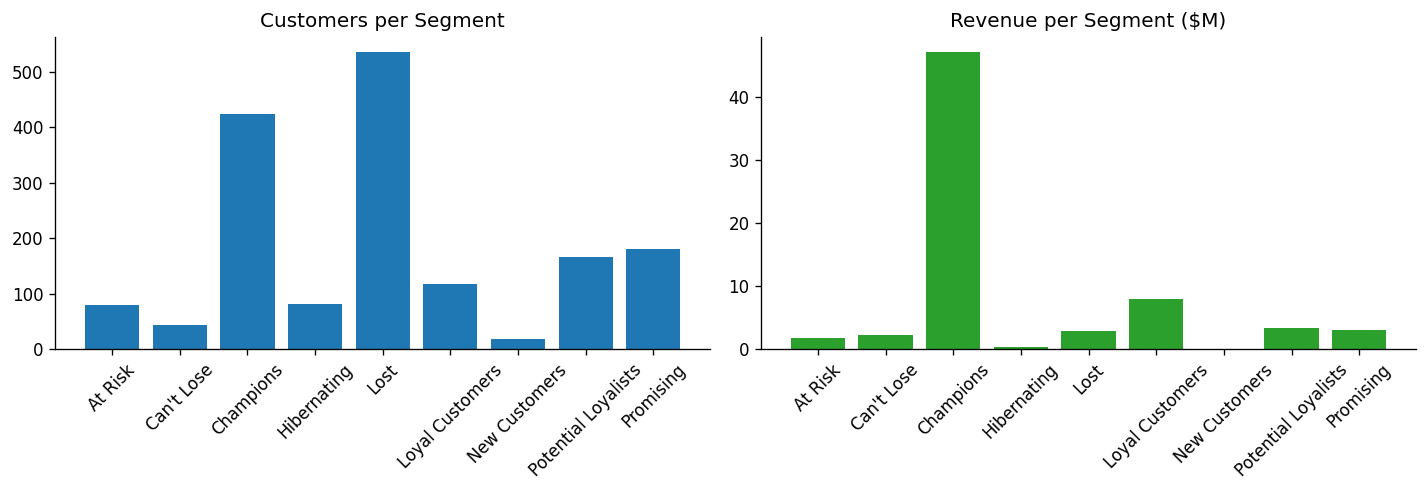

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(seg.index, seg['customers'], color='#1f77b4')
axes[0].set_title('Customers per Segment'); axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(seg.index, seg['revenue']/1e6, color='#2ca02c')
axes[1].set_title('Revenue per Segment ($M)'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 5. Export customer-level RFM for Power BI

In [6]:
rfm.to_csv('../data/cleaned/customer_rfm.csv', index=False)
print('Saved customer_rfm.csv with', len(rfm), 'customers')

Saved customer_rfm.csv with 1648 customers
